In [10]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List

In [ ]:
DATA_X = np.array([
    5.5, 8.5, 10.5, 13, 17, 20.5, 24.5, 28, 32.5, 37.5, 40.5, 42.5, 45, 47,
    49.5, 50.5, 51, 51.5, 52.5, 53, 52.8, 52, 51.5, 53, 54, 55, 56, 55.5, 54.5, 54, 55, 57, 58.5,
    59, 61.5, 62.5, 63.5, 63, 61.5, 59, 55, 53.5, 52.5, 50.5, 49.5, 50, 51, 50.5, 49, 47.5, 46,
    45.5, 45.5, 45.5, 46, 47.5, 47.5, 46, 43, 41, 41.5, 41.5, 41, 39.5, 37.5, 34.5, 31.5, 28, 24,
    21, 18.5, 17.5, 16.5, 15, 13, 10, 8, 6, 6, 6, 5.5, 3.5, 1, 0, 0, 0.5, 1.5, 3.5, 5, 5, 4.5, 4.5, 5.5,
    6.5, 6.5, 5.5
])

DATA_Y = np.array([
    41, 40.5, 40, 40.5, 41.5, 41.5, 42, 42.5, 43.5, 45, 47, 49.5, 53, 57, 59,
    59.5, 61.5, 63, 64, 64.5, 63, 61.5, 60.5, 61, 62, 63, 62.5, 61.5, 60.5, 60, 59.5, 59, 58.5,
    57.5, 55.5, 54, 53, 51.5, 50, 50, 50.5, 51, 50.5, 47.5, 44, 40.5, 36, 30.5, 28, 25.5, 21.5,
    18, 14.5, 10.5, 7.50, 4, 2.50, 1.50, 2, 3.50, 7, 12.5, 17.5, 22.5, 25, 25, 25, 25.5, 26.5,
    27.5, 27.5, 26.5, 23.5, 21, 19, 17, 14.5, 11.5, 8, 4, 1, 0, 0.5, 3, 6.50, 10, 13, 16.5, 20.5,
    25.5, 29, 33, 35, 36.5, 39, 41
])

N_POINTS = 95
NODES_T = np.linspace(0, 1, N_POINTS + 1)


def precompute_matrix_structure(t: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Argumenty:
        t: Tablica węzłów (sorted float).
    Zwraca:
        h: Tablica długości przedziałów (h_i = t_i - t_{i-1}).
        lam: Tablica współczynników lambda (pod przekątną).
        mu: Tablica współczynników mu (nad przekątną).
        p: Tablica zmodyfikowanej przekątnej po eliminacji Gaussa.
    """
    n = len(t) - 1

    # 1. Obliczamy odległości h (h[i] to odległość t[i] - t[i-1])
    # Żeby indeksowanie było wygodne (od 1), damy 0 na początku
    h = np.zeros(n + 1)
    h[1:] = np.diff(t)


    lam = np.zeros(n)
    mu = np.zeros(n)
    p = np.zeros(n)

    p[1] = 2.0


    for k in range(1, n):
        lam[k] = h[k] / (h[k] + h[k+1])
        mu[k] = 1.0 - lam[k]


        if k < n - 1:
            h_next = h[k+1]
            h_next2 = h[k+2]
            lam_next = h_next / (h_next + h_next2)
            p[k+1] = 2.0 - mu[k] * (lam_next / p[k])

    return h, lam, mu, p


def solve_moments_fast(
    y: np.ndarray,
    h: np.ndarray,
    lam: np.ndarray,
    mu: np.ndarray,
    p: np.ndarray
) -> np.ndarray:
    """
    Wylicza momenty M dla konkretnych wartości y, używając prekomputowanego p.
    """
    n = len(y) - 1
    d = np.zeros(n) # Wektor prawych stron (indeksy 1..n-1)


    #  d_k = 6 * f[t_{k-1}, t_k, t_{k+1}]
    for k in range(1, n):
        diff_right = (y[k+1] - y[k]) / h[k+1]
        diff_left = (y[k] - y[k-1]) / h[k]
        d[k] = 6.0 * (diff_right - diff_left) / (h[k] + h[k+1])


    # d_k = d_k - d_{k-1} * (lambda_k / p_{k-1})
    for k in range(2, n):
        multiplier = lam[k] / p[k-1]
        d[k] = d[k] - d[k-1] * multiplier


    M = np.zeros(n + 1)


    M[n-1] = d[n-1] / p[n-1]


    for k in range(n-2, 0, -1):
        M[k] = (d[k] - mu[k] * M[k+1]) / p[k]



    return M


def evaluate_spline_at_point(
    target_x: float,
    t_nodes: np.ndarray,
    y_nodes: np.ndarray,
    M: np.ndarray,
    h: np.ndarray
) -> float:

    n = len(t_nodes) - 1

    # 1. Znalezienie przedziału [t_{i-1}, t_i]
    # Szukamy i takiego, że t_{i-1} <= target_x <= t_i

    i = 1
    while i < n and target_x > t_nodes[i]:
        i += 1

    dt = target_x - t_nodes[i-1]
    hi = h[i]
    ai = y_nodes[i-1]
    ci = M[i-1] / 2.0
    di = (M[i] - M[i-1]) / (6.0 * hi)
    bi = (y_nodes[i] - y_nodes[i-1]) / hi - (hi / 6.0) * (2.0 * M[i-1] + M[i])

    val = ai + bi * dt + ci * (dt**2) + di * (dt**3)

    return val


def oo777():

    h, lam, mu, p = precompute_matrix_structure(NODES_T)
    M_x = solve_moments_fast(DATA_X, h, lam, mu, p)
    M_y = solve_moments_fast(DATA_Y, h, lam, mu, p)

    M_DRAW_COUNT = 1000
    u_vals = np.linspace(0, 1, M_DRAW_COUNT)

    sx_vals = []
    sy_vals = []

    for u in u_vals:
        val_x = evaluate_spline_at_point(u, NODES_T, DATA_X, M_x, h)
        val_y = evaluate_spline_at_point(u, NODES_T, DATA_Y, M_y, h)
        sx_vals.append(val_x)
        sy_vals.append(val_y)

    plt.figure(figsize=(10, 10))


    plt.plot(sx_vals, sy_vals, 'b-', linewidth=2, label='NIFS3 Parametric Curve')
    plt.plot(DATA_X, DATA_Y, 'r.', markersize=4, label='Węzły interpolacji')

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.axis('equal')


    plt.show()



4. Ewaluacja splajnów w 1000 punktach...


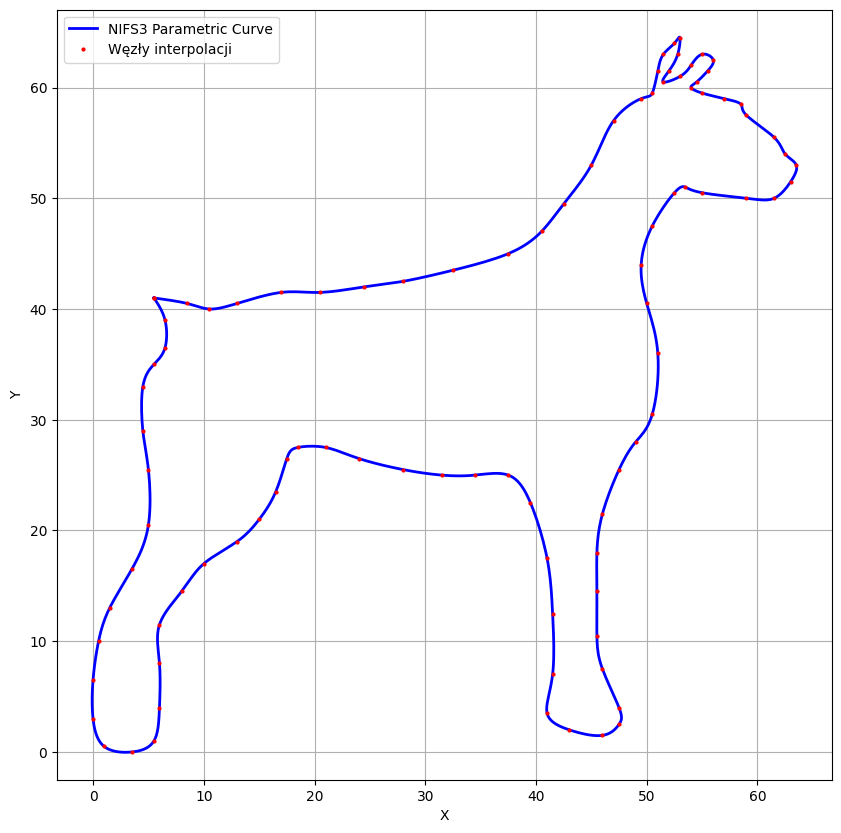

In [12]:
oo777()